# Weight Pruning vs Static-Sparse Baselines

Comparing four methods on parallel-MNIST (2 tasks, ~10 k weight budget, 1 hidden layer):

- **Dense** — fully-connected MLP
- **Block-Sparse** — oracle task-aligned blocks
- **Random-Sparse** — uniform random fan-in / fan-out per unit
- **Structure Search** — connection pruning + unit generation (proposed)

Step-size sweep (5 seeds per LR) followed by a 30-seed best-LR follow-up, in both stationary and non-stationary regimes.

In [1]:
# Run once to fetch from MLflow. Comment out after first run.
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment('paper-weight-pruning-sweep', output_dir='data', include_seed_runs=True)
# download_experiment('paper-weight-pruning-best',  output_dir='data', include_seed_runs=True)

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/mlflow/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'paper-weight-pruning-sweep' (id=26)
INFO:phd.research_utils.scripts.mlflow_download:Found 824 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 14 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['accuracy', 'accuracy_std', 'active_connections', 'active_units', 'asymptotic_accuracy', 'asymptotic_loss', 'average_loss', 'final_active_connections', 'final_active_units', 'loss', 'loss_std', 'mean_fan_in', 'mean_fan_out', 'path_purity']
Downloading: 100%|██████████| 824/824 [07:07<00:00,  1.93it/s]
IN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load data and derive `Method`

In [3]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/paper_weight_pruning_sweep_params.csv',
    'data/paper_weight_pruning_sweep_metrics.csv',
)
best_cfg, best_run = load_experiment_data(
    'data/paper_weight_pruning_best_params.csv',
    'data/paper_weight_pruning_best_metrics.csv',
)

# Drop end-of-run summary rows (loss NaN, asymptotic_loss populated) — they
# break the time-series grouping inside the plotting helpers.
def drop_summary_rows(run_dfs):
    for k, rdf in run_dfs.items():
        mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
        run_dfs[k] = rdf[~mask].copy()
    return run_dfs

drop_summary_rows(sweep_run)
drop_summary_rows(best_run)

print('Sweep buckets:', {k: len(v) for k, v in sweep_cfg.items()})
print('Best buckets :', {k: len(v) for k, v in best_cfg.items()})

Sweep buckets: {'default': 400, '02_block_sparse_lr': 10, '02_dense_lr': 10, '02_structure_search_lr': 10, '02_random_sparse_lr': 10, '01_block_sparse_lr': 10, '01_dense_lr': 10, '01_random_sparse_lr': 10, '01_structure_search_lr': 10}
Best buckets : {'default': 120, '01_random_sparse_best': 1, '01_structure_search_best': 1, '01_block_sparse_best': 1, '01_dense_best': 1}


In [4]:
# Per-seed child runs all carry sweep_name='default' (they only have a
# parentRunId tag). Trial-level rows live under the named sweeps. We use
# the children for everything: they have all the parent's hyperparams plus
# `child_seed`, which lets seaborn build proper CIs.
METHOD_ORDER = ['Dense', 'Block-Sparse', 'Random-Sparse', 'Structure Search']


def add_method_col(cfg):
    cfg = cfg.copy()
    ss = cfg.get('structure_search.enabled', pd.Series('False', index=cfg.index))
    ss = ss.astype(str).str.lower().eq('true')
    init = cfg.get('model.init_strategy', pd.Series('', index=cfg.index)).astype(str)
    method = pd.Series(index=cfg.index, dtype=object)
    method[ss] = 'Structure Search'
    method[~ss & (init == 'dense')] = 'Dense'
    method[~ss & (init == 'block_sparse')] = 'Block-Sparse'
    method[~ss & (init == 'random_sparse')] = 'Random-Sparse'
    cfg['Method'] = method
    return cfg


def gather(cfg_dfs, run_dfs, permute_period):
    """Pull all per-seed children, filter by permute_period, add Method/LR cols."""
    if 'default' not in cfg_dfs or len(cfg_dfs['default']) == 0:
        return pd.DataFrame(), pd.DataFrame()
    cfg = cfg_dfs['default'].copy()
    run = run_dfs['default'].copy()
    period = pd.to_numeric(cfg['task.permute_period'], errors='coerce')
    cfg = cfg[period == permute_period].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg = add_method_col(cfg)
    cfg = cfg[cfg['Method'].notna()].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg['optimizer.learning_rate'] = pd.to_numeric(cfg['optimizer.learning_rate'], errors='coerce')
    return cfg, run

---
## 1. Stationary  (`permute_period = 0`)

### Step-size sensitivity

Stationary sweep: 200 per-seed runs across 4 methods × 10 step-sizes


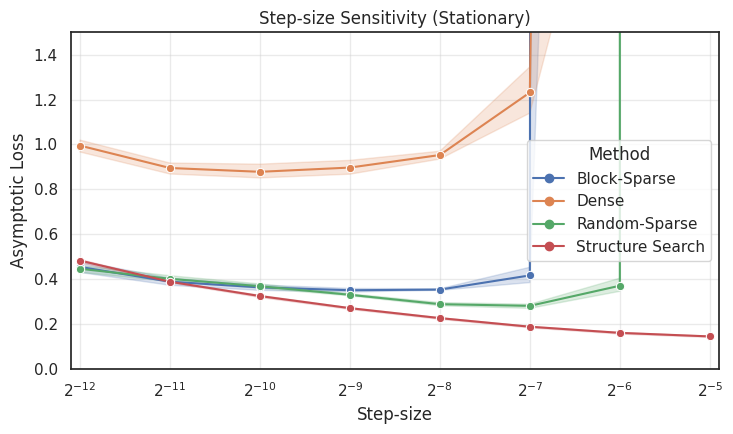

In [5]:
stat_sweep_cfg, stat_sweep_run = gather(sweep_cfg, sweep_run, permute_period=0)
print(f'Stationary sweep: {len(stat_sweep_cfg)} per-seed runs across '
      f'{stat_sweep_cfg["Method"].nunique()} methods × '
      f'{stat_sweep_cfg["optimizer.learning_rate"].nunique()} step-sizes')

plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=stat_sweep_run,
    config_df=stat_sweep_cfg,
    x_col='optimizer.learning_rate',
    title='Step-size Sensitivity (Stationary)',
    x_label='Step-size',
    y_label='Asymptotic Loss',
    metric_col='loss',
    metric_type='final_avg',
    hue_col='Method',
    legend_title='Method',
    show_ci=True,
    pow_2_x_axis=True,
    nan_policy='omit',
)
plt.ylim(0.0, 1.5)
plt.tight_layout()
plt.show()

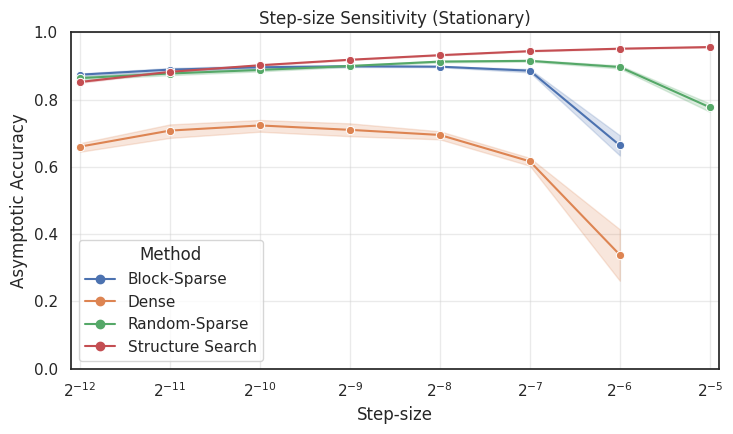

In [6]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=stat_sweep_run,
    config_df=stat_sweep_cfg,
    x_col='optimizer.learning_rate',
    title='Step-size Sensitivity (Stationary)',
    x_label='Step-size',
    y_label='Asymptotic Accuracy',
    metric_col='accuracy',
    metric_type='final_avg',
    hue_col='Method',
    legend_title='Method',
    show_ci=True,
    pow_2_x_axis=True,
    nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

### Learning curves at the best step-size  (30 seeds, 95 % CI)

Stationary best: 120 per-seed runs across 4 methods


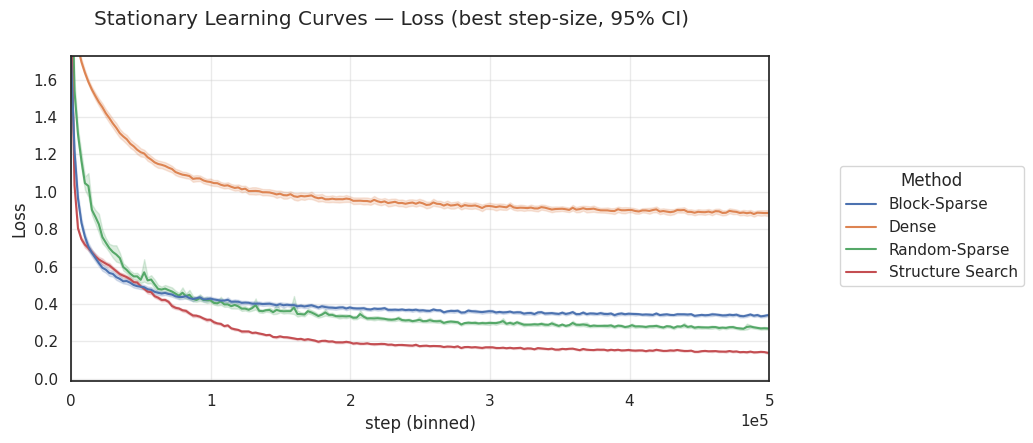

In [7]:
stat_best_cfg, stat_best_run = gather(best_cfg, best_run, permute_period=0)
print(f'Stationary best: {len(stat_best_cfg)} per-seed runs across '
      f'{stat_best_cfg["Method"].nunique()} methods')

plot_learning_curves(
    run_df=stat_best_run,
    config_df=stat_best_cfg,
    n_bins=200,
    figsize=(8, 4.5),
    y_col='loss',
    y_label='Loss',
    hue_col='Method',
    legend_title='Method',
    show_ci=True,
)
plt.suptitle('Stationary Learning Curves — Loss (best step-size, 95% CI)')
plt.tight_layout()
plt.show()

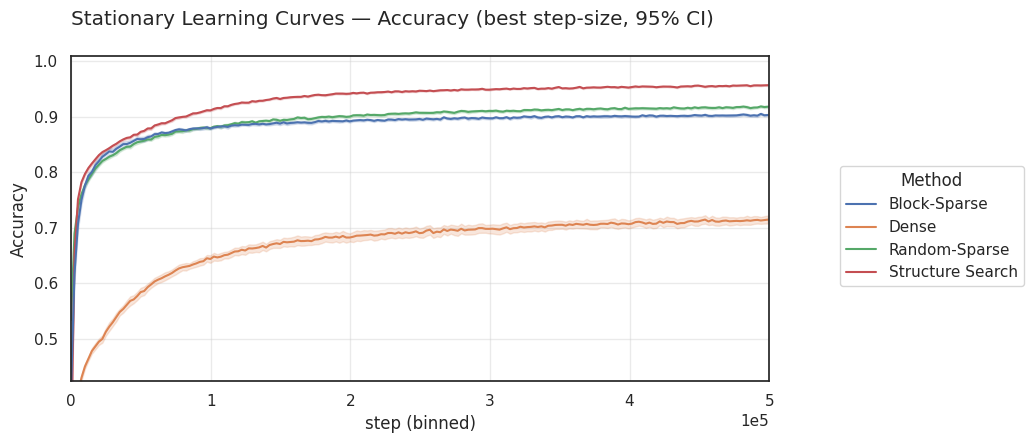

In [8]:
plot_learning_curves(
    run_df=stat_best_run,
    config_df=stat_best_cfg,
    n_bins=200,
    figsize=(8, 4.5),
    y_col='accuracy',
    y_label='Accuracy',
    hue_col='Method',
    legend_title='Method',
    show_ci=True,
)
plt.suptitle('Stationary Learning Curves — Accuracy (best step-size, 95% CI)')
plt.tight_layout()
plt.show()

---
## 2. Non-Stationary  (`permute_period = 10 000`)

### Step-size sensitivity

Non-stationary sweep: 200 per-seed runs across 4 methods


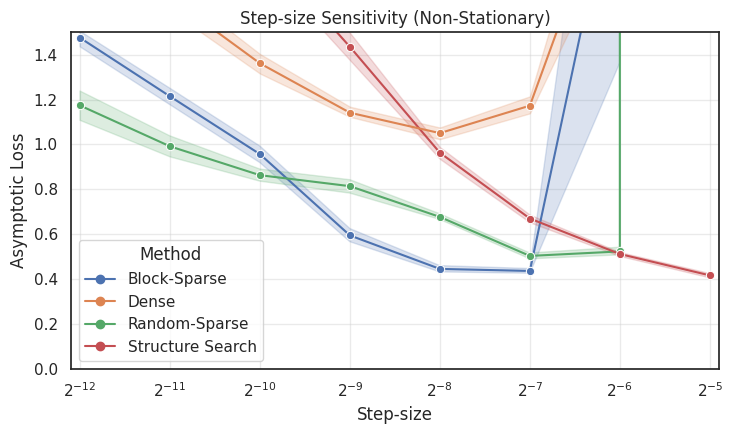

In [9]:
ns_sweep_cfg, ns_sweep_run = gather(sweep_cfg, sweep_run, permute_period=10000)
print(f'Non-stationary sweep: {len(ns_sweep_cfg)} per-seed runs across '
      f'{ns_sweep_cfg["Method"].nunique() if len(ns_sweep_cfg) else 0} methods')

if len(ns_sweep_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=ns_sweep_run,
        config_df=ns_sweep_cfg,
        x_col='optimizer.learning_rate',
        title='Step-size Sensitivity (Non-Stationary)',
        x_label='Step-size',
        y_label='Asymptotic Loss',
        metric_col='loss',
        metric_type='final_avg',
        hue_col='Method',
        legend_title='Method',
        show_ci=True,
        pow_2_x_axis=True,
        nan_policy='omit',
    )
    plt.ylim(0.0, 1.5)
    plt.tight_layout()
    plt.show()
else:
    print('No non-stationary sweep data yet — re-run the download cell once 02_*_lr finishes.')

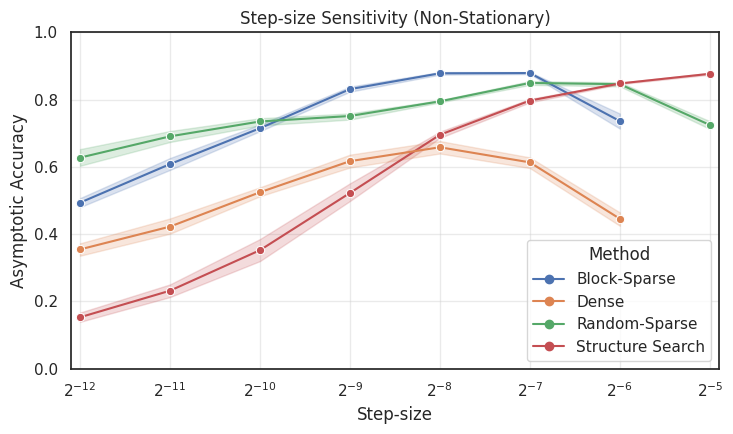

In [10]:
if len(ns_sweep_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=ns_sweep_run,
        config_df=ns_sweep_cfg,
        x_col='optimizer.learning_rate',
        title='Step-size Sensitivity (Non-Stationary)',
        x_label='Step-size',
        y_label='Asymptotic Accuracy',
        metric_col='accuracy',
        metric_type='final_avg',
        hue_col='Method',
        legend_title='Method',
        show_ci=True,
        pow_2_x_axis=True,
        nan_policy='omit',
    )
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    plt.show()

### Learning curves at the best step-size  (30 seeds, 95 % CI)

In [11]:
ns_best_cfg, ns_best_run = gather(best_cfg, best_run, permute_period=10000)
print(f'Non-stationary best: {len(ns_best_cfg)} per-seed runs across '
      f'{ns_best_cfg["Method"].nunique() if len(ns_best_cfg) else 0} methods')

if len(ns_best_cfg):
    plot_learning_curves(
        run_df=ns_best_run,
        config_df=ns_best_cfg,
        n_bins=200,
        figsize=(8, 4.5),
        y_col='loss',
        y_label='Loss',
        hue_col='Method',
        legend_title='Method',
        show_ci=True,
    )
    plt.suptitle('Non-Stationary Learning Curves — Loss (best step-size, 95% CI)')
    plt.tight_layout()
    plt.show()
else:
    print('No non-stationary best data yet — create 02_*_best configs and re-run.')

Non-stationary best: 0 per-seed runs across 0 methods
No non-stationary best data yet — create 02_*_best configs and re-run.


In [12]:
if len(ns_best_cfg):
    plot_learning_curves(
        run_df=ns_best_run,
        config_df=ns_best_cfg,
        n_bins=200,
        figsize=(8, 4.5),
        y_col='accuracy',
        y_label='Accuracy',
        hue_col='Method',
        legend_title='Method',
        show_ci=True,
    )
    plt.suptitle('Non-Stationary Learning Curves — Accuracy (best step-size, 95% CI)')
    plt.tight_layout()
    plt.show()